In [2]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad('/Users/ckw/warehouse/metacell/SEACells-main/seacell.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 700 × 786
    obs: 'label', 'SEACell', 'SEACell_type', 'metacell'
    uns: 'cell_type_colors', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [4]:
def plot_metacells( adata, title="Final Metacell Positions", min_size=50, max_size=500, show_idx=False):
    umap_coords = adata.obsm['X_umap']
    labels = adata.obs['metacell']
    metacell_coords = []
    metacell_counts = []
    present_indices = np.unique(labels)
    
    for k in present_indices:
        indices = np.where(labels == k)[0]
        metacell_coords.append(np.mean(umap_coords[indices], axis=0))
        metacell_counts.append(len(indices))
    
    metacell_coords = np.array(metacell_coords)
    metacell_counts = np.array(metacell_counts)
    
    if len(metacell_counts) == 0:
        print("警告: 没有发现活跃的 metacells。")
        return

    if len(metacell_counts) > 1 and metacell_counts.max() > metacell_counts.min():
        norm_sizes = (metacell_counts - metacell_counts.min()) / (metacell_counts.max() - metacell_counts.min())
        plot_sizes = min_size + norm_sizes * (max_size - min_size)
    else:
        plot_sizes = np.full(len(metacell_counts), (min_size + max_size) / 2)

    plt.figure(figsize=(10, 8))
    plt.scatter(umap_coords[:, 0], umap_coords[:, 1], c='lightgrey', s=5, alpha=0.5, rasterized=True)
    plt.scatter(metacell_coords[:, 0], metacell_coords[:, 1], 
                c='blue', s=plot_sizes, edgecolors='white', linewidth=1, alpha=0.8, zorder=10)
    
    min_c = metacell_counts.min()
    max_c = metacell_counts.max()
    mid_c = int((min_c + max_c) / 2)
    legend_sizes = [min_size, (min_size+max_size)/2, max_size]
    legend_labels = [f'{min_c} cells', f'{mid_c} cells', f'{max_c} cells']
    
    handles = []
    for s, l in zip(legend_sizes, legend_labels):
        handles.append(plt.scatter([], [], c='blue', alpha=0.8, s=s, edgecolors='white', label=l))
    handles.append(plt.scatter([], [], c='lightgrey', s=20, label='Single Cells'))
    
    plt.legend(handles=handles, title="Metacell Size (Count)", loc='center left', bbox_to_anchor=(1, 0.5), labelspacing=1.5, borderpad=1)
    
    if show_idx:
        for i, k in enumerate(present_indices):
            plt.text(metacell_coords[i, 0], metacell_coords[i, 1], str(k), 
                        fontsize=10, ha='center', va='center', color='black', fontweight='bold', zorder=20)
    
    plt.title(f"{title}\n(Metacells: {len(metacell_coords)}, Count Range: {min_c}-{max_c})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

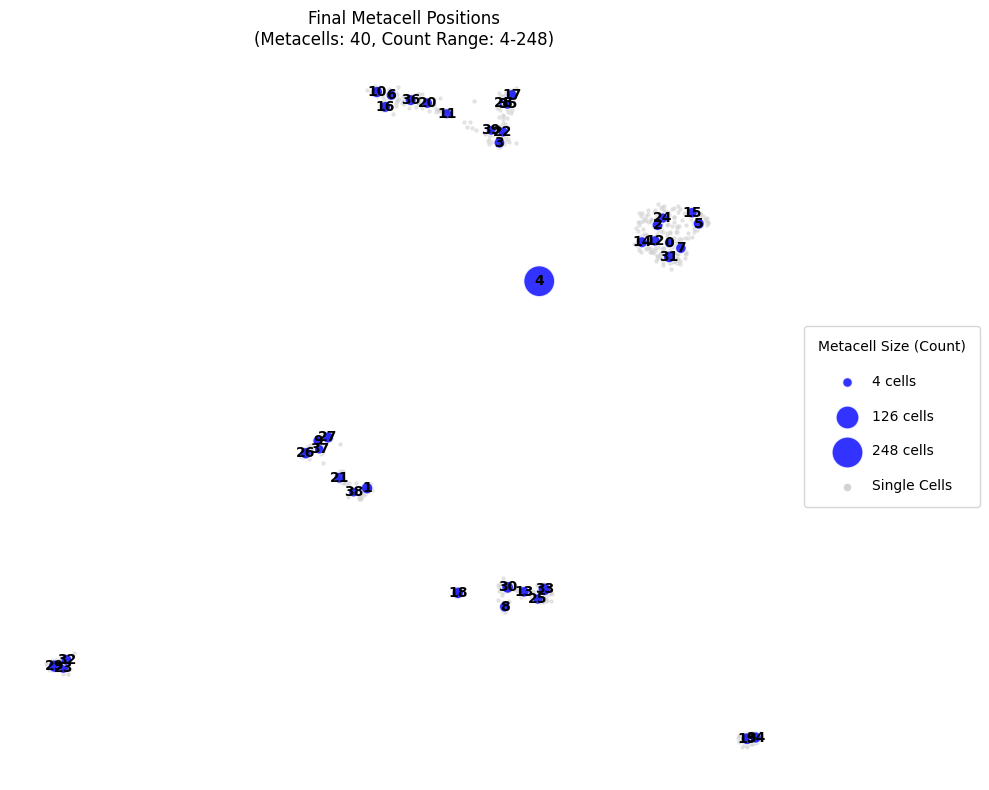

In [5]:

plot_metacells(adata, title="Final Metacell Positions", min_size=50, max_size=500, show_idx=True)

In [6]:
def evaluate_purity(adata ):    
    labels = adata.obs['metacell']
    cell_types = adata.obs['label']
    df = pd.DataFrame({'CellType': cell_types, 'Metacell': labels})

    def celltype_frac(x):
        val_counts = x['CellType'].value_counts()
        return val_counts.values[0] / val_counts.values.sum()
        
    def dominant_celltype(x):
        return x['CellType'].value_counts().index[0]

    # 聚合计算
    celltype_fraction = df.groupby("Metacell").apply(celltype_frac)
    celltype_dom = df.groupby("Metacell").apply(dominant_celltype)
    cell_num = df.groupby("Metacell").count()['CellType']

    purity = pd.concat([celltype_dom, celltype_fraction, cell_num], axis=1)
    purity.columns = ['CellType', 'CellType_purity', 'cell_num']

    # 动态计算惩罚因子与基线调整
    avg_size = purity['cell_num'].mean()
    thre = 2 * avg_size

    # 1. 过小惩罚
    purity['w_min'] = 1 - (1 / np.sqrt(purity['cell_num']))
    purity.loc[purity['cell_num'] == 1, 'w_min'] = 0.0 # 处理特例

    # 2. 过大惩罚
    excess_ratio = (purity['cell_num'] - thre) / avg_size
    excess_ratio = excess_ratio.clip(lower=0) 
    purity['w_max'] = 1 / (1 + excess_ratio)

    # 3. 机会校正基线
    num_unique_types = df['CellType'].nunique()
    baseline = 1.0 / num_unique_types
    purity['P_adj'] = (purity['CellType_purity'] - baseline) / (1 - baseline)
    purity['P_adj'] = purity['P_adj'].clip(lower=0)

    # 4. 最终核心 EP_v2
    purity['EP_v2'] = purity['P_adj'] * purity['w_min'] * purity['w_max']

    # 记录内部属性
    mean_purity_ = purity['CellType_purity'].mean()
    global_score_ = (purity['EP_v2'] * purity['cell_num']).sum() / purity['cell_num'].sum()

    # 计算 Accuracy 并映射标签以便画图
    hash_meta = purity['CellType'].to_dict()
    df['meta_lb'] = df['Metacell'].map(hash_meta)
    accuracy_ = (df['CellType'] == df['meta_lb']).sum() / df.shape[0]

    print("-" * 40)
    print(f"简单平均纯度 (Mean Purity)  : {mean_purity_:.4f}")
    print(f"模型准确率 (Accuracy)      : {accuracy_:.4f}")
    print(f"全局加权分 (Global Score)  : {global_score_:.4f}")
    print("-" * 40)

    print(f"✅ 指标计算完成！(发现 {num_unique_types} 种细胞类型)")
    return purity

In [7]:
df = evaluate_purity(adata)

----------------------------------------
简单平均纯度 (Mean Purity)  : 0.8712
模型准确率 (Accuracy)      : 0.6243
全局加权分 (Global Score)  : 0.4117
----------------------------------------
✅ 指标计算完成！(发现 14 种细胞类型)


In [8]:
def plot_metacell_sizes(purity_df, figsize=(8, 6), bins=20):

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=figsize)
    plt.hist(purity_df['cell_num'], bins=bins, color='skyblue', edgecolor='black')

    plt.title('Distribution of Metacell Sizes')
    plt.xlabel('Number of Cells')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


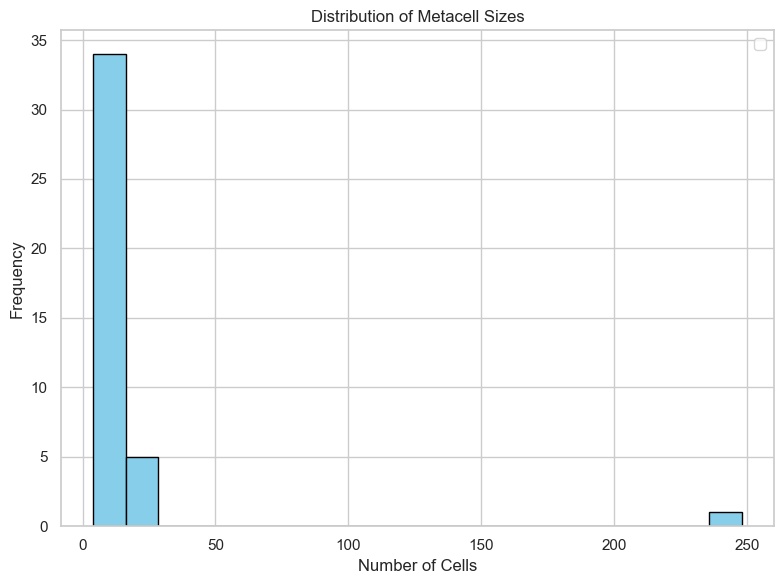

In [9]:

plot_metacell_sizes(df)